# 📧 Problem 4: Spam Detection Using Deep Learning

In [1]:

# ====================================================
# Step 1: Import Required Libraries
# ====================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    TensorDataset
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)


## 🧪 Step 2: Generate Synthetic Spam Dataset

In [3]:

# ====================================================
# Step 2: Generate Synthetic Spam Dataset
# ====================================================

n = 1000

n_not_spam = int(n * 0.7)
n_spam = n - n_not_spam

all_word_count = []
all_special_chars = []
all_uppercase_ratio = []
all_spam_words_count = []
all_is_spam = []

for _ in range(n_not_spam):

    all_word_count.append(np.random.randint(50, 800))
    all_special_chars.append(np.random.randint(0, 5))
    all_uppercase_ratio.append(np.random.uniform(0.01, 0.2))
    all_spam_words_count.append(np.random.randint(0, 5))
    all_is_spam.append(0)

for _ in range(n_spam):

    all_word_count.append(np.random.randint(10, 500))
    all_special_chars.append(np.random.randint(5, 20))
    all_uppercase_ratio.append(np.random.uniform(0.2, 0.9))
    all_spam_words_count.append(np.random.randint(10, 50))
    all_is_spam.append(1)

df = pd.DataFrame({
    "word_count": all_word_count,
    "special_chars": all_special_chars,
    "uppercase_ratio": all_uppercase_ratio,
    "spam_words_count": all_spam_words_count,
    "is_spam": all_is_spam
})

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.to_csv(
    "spam_dataset.csv",
    index=False
)

df.head()


,word_count,special_chars,uppercase_ratio,spam_words_count,is_spam
0,586,4,0.078475,4,0
1,93,7,0.348865,11,1
2,198,19,0.648760,21,1
3,332,1,0.095489,3,0
4,577,2,0.058591,1,0


## 📂 Step 3: Load Dataset

In [4]:

df = pd.read_csv("spam_dataset.csv")

print(df.shape)
print(df.head())


(1000, 5)
   word_count  special_chars  uppercase_ratio  spam_words_count  is_spam
0         586              4         0.078475                 4        0
1          93              7         0.348865                11        1
2         198             19         0.648760                21        1
3         332              1         0.095489                 3        0
4         577              2         0.058591                 1        0


## 🔄 Step 4: Separate Features and Labels

In [5]:

X = df.drop(
    columns=["is_spam"]
).values.astype(np.float32)

y = df["is_spam"].values.astype(
    np.float32
).reshape(-1, 1)

print(X.shape)
print(y.shape)


(1000, 4)
(1000, 1)


## ✂️ Step 5: Split Training and Testing Data

In [6]:

train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(len(X_train))
print(len(X_test))


800
200


## 🔢 Step 6: Convert Data Into PyTorch Tensors

In [7]:

X_train_tensor = torch.tensor(X_train)

y_train_tensor = torch.tensor(y_train)

X_test_tensor = torch.tensor(X_test)

y_test_tensor = torch.tensor(y_test)


## 📦 Step 7: Create DataLoaders

In [8]:

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


## 🧠 Step 8: Define Neural Network

In [9]:

class SpamClassifier(nn.Module):

    def __init__(self):

        super(SpamClassifier, self).__init__()

        self.fc1 = nn.Linear(4, 16)

        self.fc2 = nn.Linear(16, 8)

        self.fc3 = nn.Linear(8, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.sigmoid(self.fc3(x))

        return x

model = SpamClassifier()

print(model)


SpamClassifier(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## ⚙️ Step 9: Initialize Loss and Optimizer

In [10]:

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


## 🏋️ Step 10: Train the Model

In [11]:

epoch_predictions = []

train_losses = []

num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    with torch.no_grad():

        preds = model(
            X_train_tensor
        ).detach().cpu().numpy()

        epoch_predictions.append(
            (
                epoch + 1,
                preds,
                y_train_tensor.cpu().numpy()
            )
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {avg_loss:.4f}"
    )


Epoch [1/10], Loss: 0.9897
Epoch [2/10], Loss: 0.4422
Epoch [3/10], Loss: 0.3399
Epoch [4/10], Loss: 0.2836
Epoch [5/10], Loss: 0.2302
Epoch [6/10], Loss: 0.1708
Epoch [7/10], Loss: 0.1419
Epoch [8/10], Loss: 0.1256
Epoch [9/10], Loss: 0.1100
Epoch [10/10], Loss: 0.1031


## 📈 Step 11: Plot Training Loss

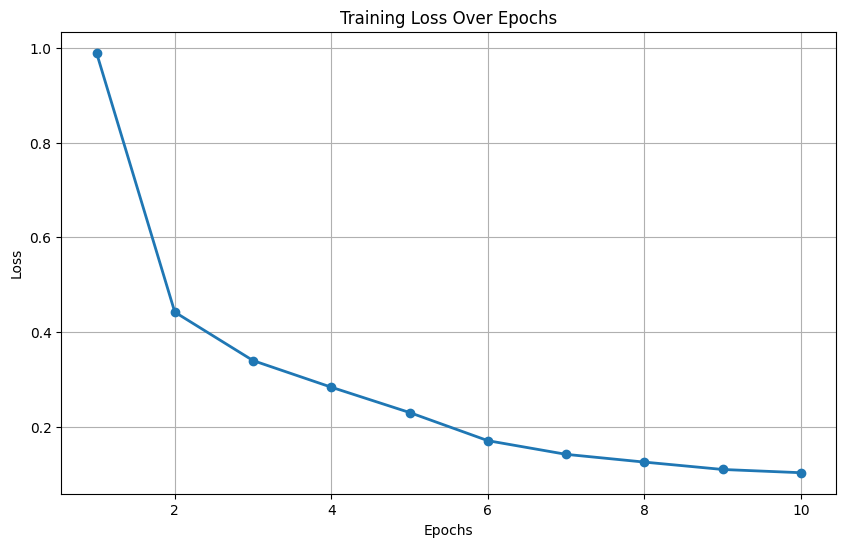

In [12]:

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o",
    linewidth=2
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)

plt.show()


## 💾 Step 12: Save Model

In [13]:

torch.save(
    model.state_dict(),
    "spam_model.pth"
)

print("Model Saved Successfully!")


Model Saved Successfully!


## 🧪 Step 13: Evaluate Model

In [14]:

model.load_state_dict(
    torch.load("spam_model.pth")
)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        predicted = (
            outputs >= 0.5
        ).float()

        total += batch_y.size(0)

        correct += (
            predicted == batch_y
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.00%
